# E-commerce Funnel and Device Friction

**Author: Tajamul Khan**

Where do shoppers abandon the purchase journey?

Original synthetic teaching data. All outputs below are calculated by executing these cells. This is an analytical portfolio case study, not a real client engagement.

## Situation and task

A store sees many visits but few completed purchases and needs a device-level diagnosis.

Build a strictly ordered session funnel and quantify the largest observed transition loss.

## Data contract and KPI definitions

One row per session; funnel flags are nested in visit → product_view → add_to_cart → checkout → purchase order. Overall conversion uses all sessions; checkout completion uses only sessions that reached checkout.

See `data/README.md` for field types, source and seed.

In [1]:
from pathlib import Path
import json, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
BASE = Path.cwd()
assert (BASE/'data/raw.csv').exists(), 'Run from this project directory'
OUT = BASE/'outputs'
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
df = pd.read_csv(BASE/'data/raw.csv')
if 'date' in df:
    df['date'] = pd.to_datetime(df['date'])
print('Raw shape:',df.shape)
display(df.head())


Raw shape: (9000, 8)


,session_id,date,device,visit,product_view,add_to_cart,checkout,purchase
0,1,2025-08-07,Mobile,1,1,1,0,0
1,2,2025-04-01,Mobile,1,0,0,0,0
2,3,2025-09-29,Mobile,1,1,0,0,0
3,4,2025-12-27,Desktop,1,1,1,1,1
4,5,2025-05-03,Mobile,1,0,0,0,0


## Validate the source

Inspect missingness and grain before computing metrics. Missing outcomes are not automatically zeros.

In [2]:
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'unique_values':df.nunique()})
display(audit)
print('Exact duplicate rows:',df.duplicated().sum())
audit.to_csv(OUT/'data_quality.csv')


Exact duplicate rows: 0


,dtype,missing,unique_values
session_id,int64,0,9000
date,datetime64[ns],0,365
device,object,0,3
visit,int64,0,1
product_view,int64,0,2
add_to_cart,int64,0,2
checkout,int64,0,2
purchase,int64,0,2


## Action: analysis

Validate nested funnel flags, compute conditional step conversion and compare device segments.

In [3]:
steps=['visit','product_view','add_to_cart','checkout','purchase']
assert df.session_id.is_unique
assert (df[steps].diff(axis=1).iloc[:,1:]<=0).all().all()
funnel=df[steps].sum().to_frame('sessions'); funnel['previous_step_conversion_pct']=100*funnel.sessions/funnel.sessions.shift(1)
funnel.to_csv(OUT/'funnel.csv')
summary=df.groupby('device')[steps].sum(); summary['purchase_rate_pct']=100*summary.purchase/summary.visit
metrics={'Sessions':len(df),'Session conversion (%)':100*df.purchase.mean(),'Checkout completion (%)':100*df.purchase.sum()/df.checkout.sum()}
chart=funnel.sessions; ylabel='Sessions reaching step'

## Deep dive: Conditional funnel conversion by device

Compare step-level conversion using only sessions that reached the previous step. This localizes friction more precisely than overall conversion.

Mobile has the lowest observed checkout completion (51.05%). Audit its payment journey and validate any fix with an experiment.
Out[4]: 128


,product_view,add_to_cart,checkout,purchase
device,,,,
Desktop,75.17,39.45,74.20,70.79
Mobile,75.85,37.24,71.87,51.05
Tablet,77.59,39.02,77.92,76.11


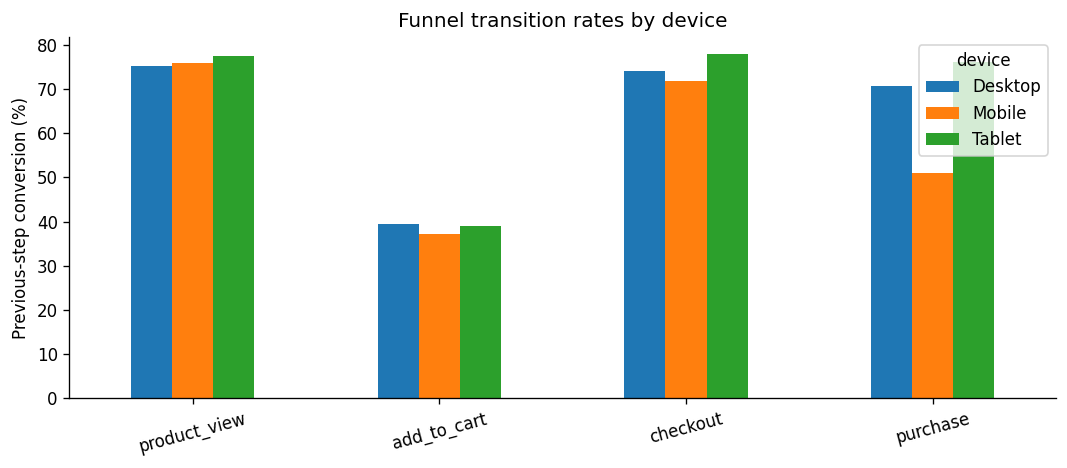

In [4]:

detail=pd.DataFrame({steps[j]:100*summary[steps[j]]/summary[steps[j-1]].replace(0,np.nan) for j in range(1,len(steps))})
display(detail.round(2))
fig,ax=plt.subplots(figsize=(9,4));detail.T.plot.bar(ax=ax,rot=15);ax.set_ylabel('Previous-step conversion (%)');ax.set_title('Funnel transition rates by device');fig.tight_layout();fig.savefig(OUT/'detail.png');plt.show()
worst=detail.purchase.idxmin()
recommendation=f'{worst} has the lowest observed checkout completion ({detail.loc[worst,"purchase"]:.2f}%). Audit its payment journey and validate any fix with an experiment.'

detail.to_csv(OUT/'detail.csv')
print(recommendation)
(OUT/'recommendation.txt').write_text(recommendation+'\n')


## Results: calculated evidence

These describe only the included synthetic dataset. They do not measure deployed impact.

In [5]:
display(summary.round(4))
display(pd.Series(metrics,name='value').to_frame())
summary.to_csv(OUT/'summary.csv')
(OUT/'metrics.json').write_text(json.dumps({k:float(v) for k,v in metrics.items()},indent=2))
df.to_csv(OUT/'analysis_ready.csv',index=False)
assert all(np.isfinite(float(v)) for v in metrics.values()), 'Invalid KPI'


,visit,product_view,add_to_cart,checkout,purchase,purchase_rate_pct
device,,,,,,
Desktop,2863,2152,849,630,446,15.5781
Mobile,5374,4076,1518,1091,557,10.3647
Tablet,763,592,231,180,137,17.9554


,value
Sessions,9000.000000
Session conversion (%),12.666667
Checkout completion (%),59.968438


## SQL cross-check

Load validated facts into SQLite and reconcile shared aggregates against Python.

In [6]:
with sqlite3.connect(':memory:') as conn:
    df.to_sql('facts',conn,index=False,if_exists='replace')
    sql_result=pd.read_sql_query((BASE/'analysis.sql').read_text(),conn)
display(sql_result)
sql_result.to_csv(OUT/'sql_results.csv',index=False)
# Reconcile at least one common aggregate by group, rather than trusting the SQL output.
sql_result=sql_result.rename(columns={'sessions':'visit'})
key=sql_result.columns[0]
py=summary.reset_index()
common=[c for c in sql_result.columns[1:] if c in py.columns]
assert common, 'No comparable aggregate'
joined=sql_result.merge(py,on=key,suffixes=('_sql','_python'),validate='one_to_one')
assert len(joined)==len(summary)==len(sql_result)
for col in common:
    assert np.allclose(joined[col+'_sql'],joined[col+'_python'],rtol=1e-8,atol=1e-6), col
print('SQL / Python reconciliation passed:',common)


SQL / Python reconciliation passed: ['visit', 'purchase_rate_pct']


,device,sessions,purchase_rate_pct
0,Desktop,2863,15.578065
1,Mobile,5374,10.364719
2,Tablet,763,17.955439


## Visual interpretation

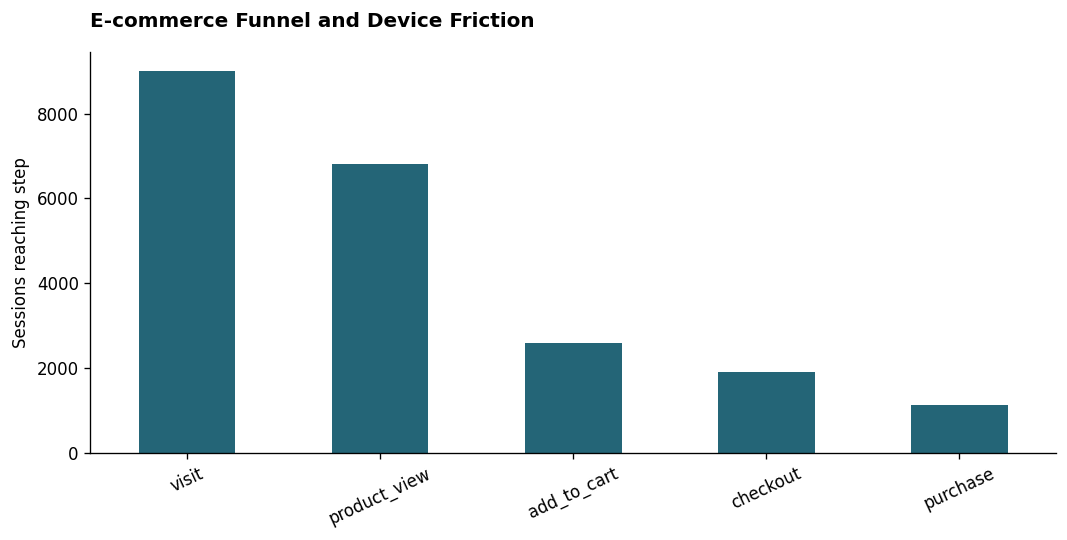

In [7]:
fig,ax=plt.subplots(figsize=(9,4.6))
chart.plot(kind='bar',ax=ax,color='#246577',rot=25)
ax.set_ylabel(ylabel)
ax.set_xlabel('')
ax.set_title('E-commerce Funnel and Device Friction',loc='left',fontweight='bold',pad=15)
fig.tight_layout()
fig.savefig(OUT/'overview.png',bbox_inches='tight')
plt.show()


## Offline dashboard

The KPI cards and chart are a fixed analysis snapshot. The row filter searches the summary table; it does not recompute the KPIs.

In [8]:
# Standalone dashboard: no remote JavaScript, server or account required.
import html, base64
cards=''.join('<article><span>'+html.escape(k)+'</span><strong>'+f'{v:,.4f}'+'</strong></article>' for k,v in metrics.items())
image=base64.b64encode((OUT/'overview.png').read_bytes()).decode()
table=summary.round(4).to_html(classes='data',border=0)
page='''<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1"><title>E-commerce Funnel and Device Friction</title>
<style>body{font:16px system-ui;margin:0;background:#f3f5f7;color:#172c3b}main{max-width:1100px;margin:auto;padding:36px}header{border-bottom:3px solid #246577;margin-bottom:24px}small{color:#51616c}.cards{display:flex;gap:14px;flex-wrap:wrap}article{background:white;padding:18px;border:1px solid #d7e0e5;flex:1;min-width:175px}strong{display:block;font-size:27px;margin-top:12px}img{max-width:100%;margin-top:24px}table{border-collapse:collapse;background:white;width:100%;font-size:14px}td,th{padding:12px;text-align:right;border-bottom:1px solid #d7e0e5}input{padding:12px;margin:20px 0;width:280px;max-width:90%}.scroll{overflow:auto}footer{margin-top:24px}</style>
<main><header><small>TAJAMUL KHAN · DATA ANALYST PORTFOLIO</small><h1>E-commerce Funnel and Device Friction</h1><p>Where do shoppers abandon the purchase journey?</p><p><b>Synthetic teaching data · Fictional 2025 case study</b></p></header><section class="cards">'''+cards+'''</section><img alt="Analysis overview chart" src="data:image/png;base64,'''+image+'''"><h2>Explore summary groups</h2><label for="filter">Filter summary rows</label><br><input id="filter" placeholder="Type a group name"><div class="scroll">'''+table+'''</div><p>The session is the unit, so cross-device and multi-session journeys are excluded. Counts represent opportunities, not recoverable revenue.</p><footer>Instagram @tajamul.codes · linkedin.com/in/tajamulkhann/</footer></main>
<script>document.getElementById('filter').addEventListener('input',function(){const q=this.value.toLowerCase();document.querySelectorAll('tbody tr').forEach(r=>r.hidden=!r.textContent.toLowerCase().includes(q))});</script></html>'''
detail_image=base64.b64encode((OUT/'detail.png').read_bytes()).decode()
page=page.replace('<h2>Explore summary groups</h2>','<h2>Analyst finding</h2><p>'+html.escape(recommendation)+'</p><img alt="Supporting analysis" src="data:image/png;base64,'+detail_image+'"><h2>Explore summary groups</h2>')
(OUT/'dashboard.html').write_text(page)
print('Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.')


Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.


## Decision, limitations and next step

The session is the unit, so cross-device and multi-session journeys are excluded. Counts represent opportunities, not recoverable revenue.

**Next step:** Instrument timestamped events and test the suspected checkout friction.

Use the result table to identify a priority for investigation. Avoid claiming that the suggested action has already delivered a business improvement.

## Career discussion

Explain the business question, data grain, denominator, validation, strongest finding and one limitation. Use the README STAR story only after reproducing and understanding this project.